# CIFAR-10 CNN: HOSVD vs HOOI fine-tuning comparison

同じ balanced rank / baseline / data split / optimizer / seed / Early Stopping 条件で、HOSVD Tucker-2 と HOOI Tucker-2 を fine-tuning する。

見るものは **fine-tuning後の精度、回復量、best epoch、学習曲線**。HOOIのweight近似改善がtask accuracyの回復にも効くかを検証する。

`SEEDS=[0]` で03と揃えた単一seed比較を行い、差が小さければ `[0,1,2]` に変更して複数seedで確認する。


device: cuda
balanced rank: (32, 16) baseline val/test: 0.7344 0.7327
method='hosvd' seed=0
epoch=01 train_loss=0.6974 train_acc=0.7529 val_loss=0.7809 val_acc=0.7284
epoch=02 train_loss=0.6866 train_acc=0.7586 val_loss=0.7675 val_acc=0.7354
epoch=03 train_loss=0.6822 train_acc=0.7559 val_loss=0.7746 val_acc=0.7328
epoch=04 train_loss=0.6710 train_acc=0.7649 val_loss=0.7598 val_acc=0.7342
epoch=05 train_loss=0.6699 train_acc=0.7648 val_loss=0.7601 val_acc=0.7398
epoch=06 train_loss=0.6610 train_acc=0.7653 val_loss=0.7509 val_acc=0.7376
epoch=07 train_loss=0.6603 train_acc=0.7695 val_loss=0.7547 val_acc=0.7408
epoch=08 train_loss=0.6668 train_acc=0.7642 val_loss=0.7567 val_acc=0.7396
epoch=09 train_loss=0.6528 train_acc=0.7695 val_loss=0.7434 val_acc=0.7432
epoch=10 train_loss=0.6404 train_acc=0.7742 val_loss=0.7392 val_acc=0.7486
epoch=11 train_loss=0.6441 train_acc=0.7725 val_loss=0.7408 val_acc=0.7454
epoch=12 train_loss=0.6422 train_acc=0.7729 val_loss=0.7406 val_acc=0.7446
epoch=13

,method,seed,rank_out,rank_in,pre_weight_relative_error,post_weight_relative_error,pre_validation_rank_acc,post_validation_rank_acc,validation_recovery,pre_test_acc,post_test_acc,test_recovery,test_gap_to_baseline,best_epoch,best_validation_loss,epochs_ran,parameters,hooi_iterations
0,hosvd,0,32,16,0.449042,0.483660,0.6280,0.7528,0.1248,0.6378,0.7508,0.1130,0.0181,17,0.717830,20,117578,0
1,hooi,0,32,16,0.442504,0.481255,0.6202,0.7528,0.1326,0.6257,0.7555,0.1298,0.0228,17,0.714387,20,117578,5


,method,seed,pre_weight_relative_error,pre_validation_rank_acc,post_validation_rank_acc,validation_recovery,pre_test_acc,post_test_acc,test_recovery,test_gap_to_baseline,best_epoch,epochs_ran,post_weight_relative_error
0,hosvd,0,0.449042,0.6280,0.7528,0.1248,0.6378,0.7508,0.1130,0.0181,17,20,0.483660
1,hooi,0,0.442504,0.6202,0.7528,0.1326,0.6257,0.7555,0.1298,0.0228,17,20,0.481255


,metric,HOOI_minus_HOSVD
0,post_validation_rank_acc,0.0000
1,post_test_acc,0.0047
2,validation_recovery,0.0078
3,test_recovery,0.0168
4,best_epoch,0.0000


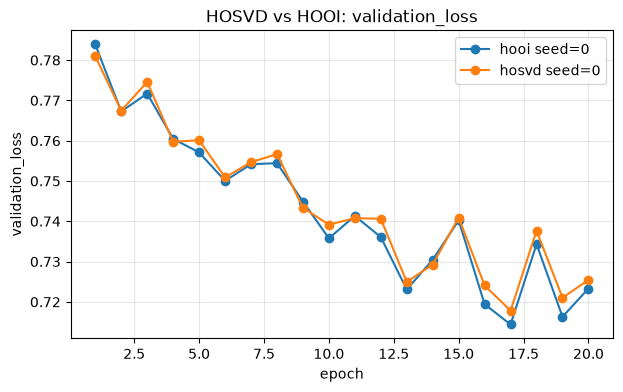

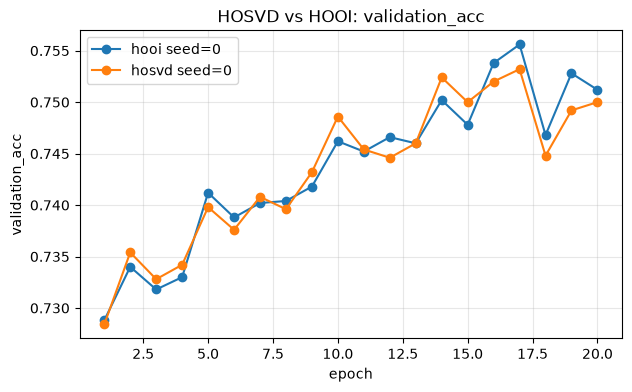

差が小さければ SEEDS=[0,1,2] に変更して再実行。
saved: D:\dev\nn-compression-svd-dmrg\results\20_tucker\10_cifar10_cnn\05_hosvd_vs_hooi_finetuning


In [1]:
from __future__ import annotations
from pathlib import Path
import copy, sys
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "src/nn_compression").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from nn_compression.compression import (
    build_tucker2_conv,
    build_tucker2_conv_from_components,
    tucker2_effective_weight,
    tucker2_hooi as _tucker2_hooi_src,
)
from nn_compression.datasets import shuffled_index_splits
from nn_compression.metrics import count_parameters, relative_frobenius_error
from nn_compression.models import CIFAR10CNN
from nn_compression.training import evaluate, fit_with_early_stopping, non_shuffling_loader
from nn_compression.utils import find_project_root, get_experiment_dirs, set_seed

# --- config: 03_finetuning と同じ条件 ---
root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    root, "20_tucker", "10_cifar10_cnn", "05_hosvd_vs_hooi_finetuning"
)
selected_csv = root / "results/20_tucker/10_cifar10_cnn/02_rank_sweep/selected_rank_settings.csv"
baseline_path = root / "models/10_svd/40_cifar10_cnn/02_svd_global_compression_using_src_corrected/cifar10_cnn_baseline.pt"
SEED, LR, MAX_EPOCHS, PATIENCE, MIN_DELTA = 0, 3e-4, 30, 3, 1e-4
BATCH_SIZE, NUM_WORKERS = 256, 0
HOOI_MAX_ITERS, HOOI_ABS_TOL, HOOI_REL_TOL = 30, 1e-8, 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
print("device:", device)

# --- data: train 40k / early-stop val 5k / comparison val 5k / test 10k ---
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize((.5,.5,.5),(.5,.5,.5))
])
eval_tf = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((.5,.5,.5),(.5,.5,.5))
])
train_aug = datasets.CIFAR10(data_dir, train=True, download=False, transform=train_tf)
train_eval = datasets.CIFAR10(data_dir, train=True, download=False, transform=eval_tf)
test_ds = datasets.CIFAR10(data_dir, train=False, download=False, transform=eval_tf)
tr_idx, es_idx, vr_idx = shuffled_index_splits(len(train_aug), (40_000, 5_000, 5_000), seed=SEED)
train_ds, es_ds, vr_ds = Subset(train_aug,tr_idx), Subset(train_eval,es_idx), Subset(train_eval,vr_idx)
def eval_loader(ds): return DataLoader(ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=device.type=="cuda")
es_loader, vr_loader, test_loader = eval_loader(es_ds), eval_loader(vr_ds), eval_loader(test_ds)
def train_loaders(seed):
    g = torch.Generator().manual_seed(seed)
    x = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=device.type=="cuda",generator=g)
    return x, non_shuffling_loader(x)

# --- baseline + balanced rank ---
sel = pd.read_csv(selected_csv)
bal = sel[sel["role"]=="balanced"]
if len(bal) != 1: raise ValueError("balanced rank は1行必要です。")
rank_out, rank_in = int(bal.iloc[0]["rank_out"]), int(bal.iloc[0]["rank_in"])
baseline = CIFAR10CNN().to(device)
ckpt = torch.load(baseline_path,map_location=device,weights_only=False)
baseline.load_state_dict(ckpt["model_state_dict"] if isinstance(ckpt,dict) and "model_state_dict" in ckpt else ckpt)
baseline.eval()
_, base_vr = evaluate(baseline,vr_loader,criterion,device)
_, base_test = evaluate(baseline,test_loader,criterion,device)
W0 = baseline.conv2.weight.detach().clone()
print("balanced rank:", (rank_out,rank_in), "baseline val/test:", base_vr, base_test)

# --- Tucker-2 HOOI: src/nn_compression/compression/hooi.py, conv_tucker.py ---

def tucker2_hooi(W, ro, ri):
    """HOOI 分解。history[1:] を sweep ごとの DataFrame にする。"""
    core, factors, history = _tucker2_hooi_src(
        W, ro, ri,
        max_iter=HOOI_MAX_ITERS,
        abs_tol=HOOI_ABS_TOL,
        rel_tol=HOOI_REL_TOL,
    )
    hist = pd.DataFrame({
        "iteration": range(1, len(history)),
        "weight_relative_error": history[1:],
    })
    return core, factors, hist

def initialized(method):
    m=copy.deepcopy(baseline)
    if method=="hosvd":
        m.conv2=build_tucker2_conv(m.conv2,rank_out,rank_in); hh=None
    elif method=="hooi":
        core,factors,hh=tucker2_hooi(m.conv2.weight.detach(),rank_out,rank_in)
        m.conv2=build_tucker2_conv_from_components(m.conv2,core,factors[0],factors[1])
    else: raise ValueError(method)
    return m.to(device),hh

# --- fine-tuning: method以外の条件を固定 ---
def run(method,seed):
    set_seed(seed); m,hh=initialized(method); m.eval()
    pre_err=float(relative_frobenius_error(W0,tucker2_effective_weight(m.conv2)))
    _,pre_vr=evaluate(m,vr_loader,criterion,device); _,pre_test=evaluate(m,test_loader,criterion,device)

    set_seed(seed)  # augmentation/shuffleの乱数系列を揃える
    tr_loader,tr_eval_loader=train_loaders(seed)
    opt=torch.optim.Adam(m.parameters(),lr=LR)
    fit=fit_with_early_stopping(
        model=m,train_loader=tr_loader,val_loader=es_loader,criterion=criterion,optimizer=opt,device=device,
        max_epochs=MAX_EPOCHS,patience=PATIENCE,min_delta=MIN_DELTA,
        reevaluate_train=True,log_every_epoch=True,train_eval_loader=tr_eval_loader
    )
    m=fit["model"]; m.eval()
    _,post_vr=evaluate(m,vr_loader,criterion,device); _,post_test=evaluate(m,test_loader,criterion,device)
    post_err=float(relative_frobenius_error(W0,tucker2_effective_weight(m.conv2)))
    hist=pd.DataFrame(fit["history"]); hist.insert(0,"method",method); hist.insert(1,"seed",seed)
    row=dict(
        method=method,seed=seed,rank_out=rank_out,rank_in=rank_in,
        pre_weight_relative_error=pre_err,post_weight_relative_error=post_err,
        pre_validation_rank_acc=pre_vr,post_validation_rank_acc=post_vr,validation_recovery=post_vr-pre_vr,
        pre_test_acc=pre_test,post_test_acc=post_test,test_recovery=post_test-pre_test,
        test_gap_to_baseline=post_test-base_test,best_epoch=fit["best_epoch"],
        best_validation_loss=fit["best_validation_loss"],epochs_ran=len(hist),
        parameters=count_parameters(m),hooi_iterations=0 if hh is None else len(hh)
    )
    torch.save({"model_state_dict":m.state_dict(),"method":method,"seed":seed,"rank_out":rank_out,"rank_in":rank_in,"best_epoch":fit["best_epoch"]},
               models_dir/f"{method}_seed{seed}.pt")
    return row,hist,hh

# --- run: まずseed=0。差が小さければ [0,1,2] に変更 ---
SEEDS=[0]
rows=[]; histories=[]; hooi_histories={}
for seed in SEEDS:
    for method in ["hosvd","hooi"]:
        print("="*70, f"\n{method=} {seed=}")
        row,hist,hh=run(method,seed); rows.append(row); histories.append(hist)
        if hh is not None: hooi_histories[seed]=hh

comparison=pd.DataFrame(rows)
history_all=pd.concat(histories,ignore_index=True)
display(comparison)

# --- direct comparison ---
cols=["method","seed","pre_weight_relative_error","pre_validation_rank_acc","post_validation_rank_acc",
      "validation_recovery","pre_test_acc","post_test_acc","test_recovery","test_gap_to_baseline",
      "best_epoch","epochs_ran","post_weight_relative_error"]
summary=comparison[cols]; display(summary)
if len(SEEDS)==1:
    h=summary[summary.method=="hosvd"].iloc[0]; o=summary[summary.method=="hooi"].iloc[0]
    display(pd.DataFrame({
        "metric":["post_validation_rank_acc","post_test_acc","validation_recovery","test_recovery","best_epoch"],
        "HOOI_minus_HOSVD":[o.post_validation_rank_acc-h.post_validation_rank_acc,o.post_test_acc-h.post_test_acc,
                            o.validation_recovery-h.validation_recovery,o.test_recovery-h.test_recovery,o.best_epoch-h.best_epoch]
    }))

# --- learning curves ---
for metric in ["validation_loss","validation_acc"]:
    plt.figure(figsize=(7,4))
    for (method,seed),part in history_all.groupby(["method","seed"]):
        plt.plot(part.epoch,part[metric],marker="o",label=f"{method} seed={seed}")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(f"HOSVD vs HOOI: {metric}")
    plt.grid(True,alpha=.3); plt.legend(); plt.show()

# --- multi-seed summary ---
if len(SEEDS)>1:
    display(comparison.groupby("method").agg(
        post_test_mean=("post_test_acc","mean"),post_test_std=("post_test_acc","std"),
        recovery_mean=("test_recovery","mean"),recovery_std=("test_recovery","std"),
        best_epoch_mean=("best_epoch","mean")
    ).reset_index())
else:
    print("差が小さければ SEEDS=[0,1,2] に変更して再実行。")

# --- save ---
results_dir.mkdir(parents=True,exist_ok=True)
comparison.to_csv(results_dir/"hosvd_vs_hooi_finetuning.csv",index=False)
history_all.to_csv(results_dir/"finetuning_history.csv",index=False)
for seed,h in hooi_histories.items():
    h.to_csv(results_dir/f"hooi_initialization_history_seed{seed}.csv",index=False)
print("saved:",results_dir)


## 結果の読み方

- HOOIの最終精度が高い: weight近似改善がfine-tuning初期値としても有利な可能性。
- 最終精度は同じだがHOOIのbest epochが早い: optimization上の初期値として有利な可能性。
- ほぼ同じ: fine-tuningが初期化差を吸収した可能性。追加HOOIコストの実用価値は小さい。
- HOOIの方が悪い: Frobenius誤差の改善とtask lossの改善は別であることを示す。
